In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

e:\Projects\Customer Churn Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\shega\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv(path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe().round()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.0,7043.0,7043.0
mean,0.0,32.0,65.0
std,0.0,25.0,30.0
min,0.0,0.0,18.0
25%,0.0,9.0,36.0
50%,0.0,29.0,70.0
75%,0.0,55.0,90.0
max,1.0,72.0,119.0


Converting Total Charges column into numeric column

In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

Checking Null Values
> 11 Null Values found in Total Charges





In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
# Filling in Null values in Totla charges with mean of it
df.fillna(df['TotalCharges'].mean(), inplace=True)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


Checking Duplicated Values

> No Duplicate values found




In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['customerID'].duplicated().sum()

np.int64(0)

There is a Imbalance in the Data

In [13]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Droping the CustomerID as it is not useful

In [14]:
df.drop('customerID', axis=1, inplace=True)

### **Univariate Analysis**

Insights from Numeric Features
*  Only 16% of customers are senior citizens.
*  Customers stay with the company about 32 months on average.
*   Monthly charges range from low-cost plans 18rs  to premium plans 118rs

*   Total charges show high variability, indicating different customer lifetimes and service usage.
*  The dataset contains both new customers and long-term customers (up to 6 years)



In [15]:
numeric_features = df.select_dtypes(include=['number']).columns
for col in numeric_features:
  print(col)
  print(df[col].describe())
  print("\n")

SeniorCitizen
count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64


tenure
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


MonthlyCharges
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


TotalCharges
count    7043.000000
mean     2283.300441
std      2265.000258
min        18.800000
25%       402.225000
50%      1400.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64




Insights From Categorical Features

*   Most customers do not use multiple lines
*   Fiber optic is the most used internet service
*  Majority of customers do not use to online security services
*  Most customers do not use online backup services
*   less than half of the customers uses device protection  
*   Technical support services are used by a less customers
*   Most customers prefer Month-to-Month contracts
*  Electronic check is the most used payment method
*   A significant portion of customers do not use internet services









In [16]:
categorical_features=[]
for col in df:
  val=df[col].nunique()
  if val > 2 and val < 10:
    categorical_features.append(col)
    print(df[col].value_counts())
    print("\n")

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64


StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64


StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64


Contract
Month-to-mont

## **Bivariate Analysis**

# Churn Insights
Contract type strongly affects churn:
Month-to-month customers churn the most (~43%), while long-term contracts reduce churn significantly.

Fiber optic users have the highest churn (~42%), suggesting possible price or service issues.

Lack of Tech Support and Online Security is associated with high churn (~41%).

Customers with add-on services (Backup, Device Protection) churn less (~21–22%).

Electronic check payment users show the highest churn (~45%), while automatic payments reduce churn.

Streaming services have weak influence on churn (~30–33%).

MultipleLines has minimal impact on churn

Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896


Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194


Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494


Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                

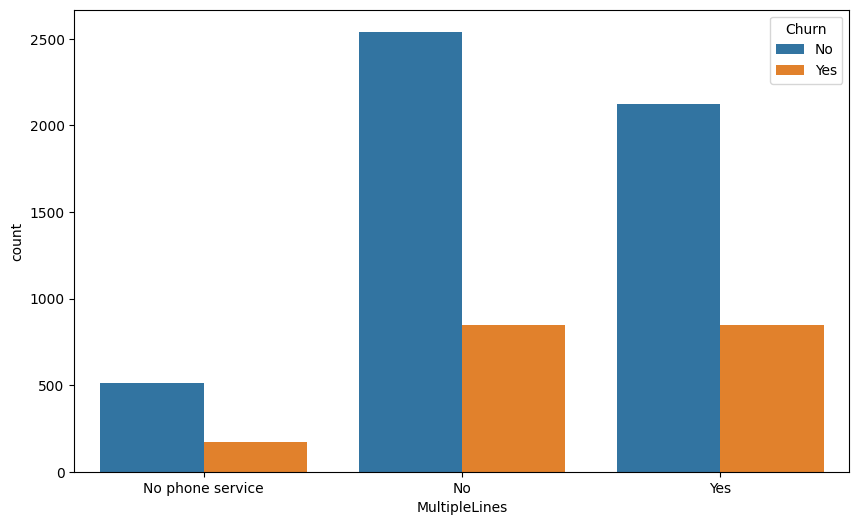

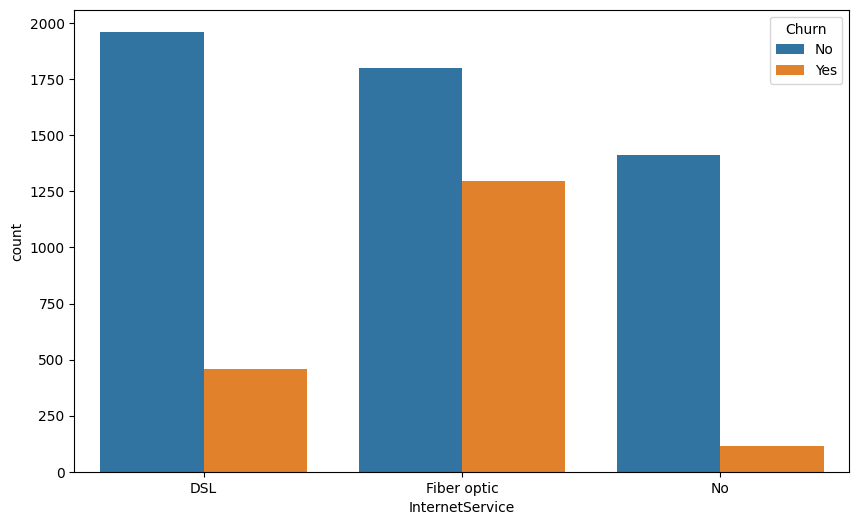

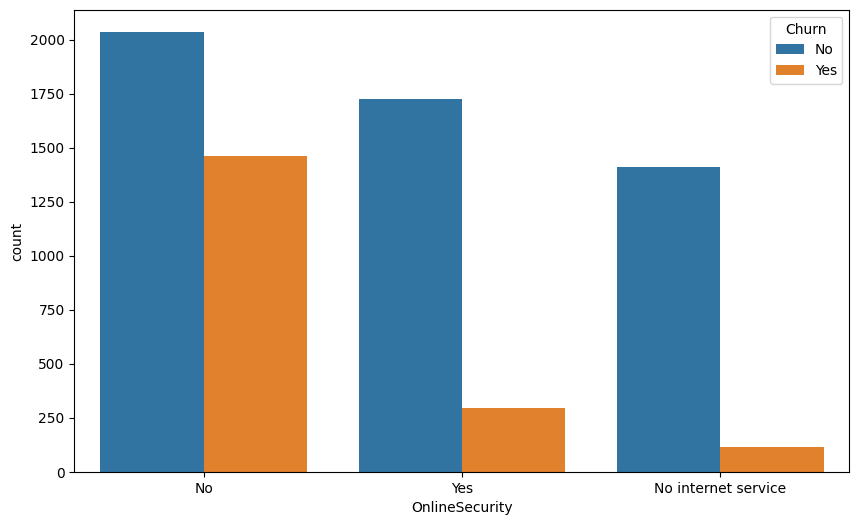

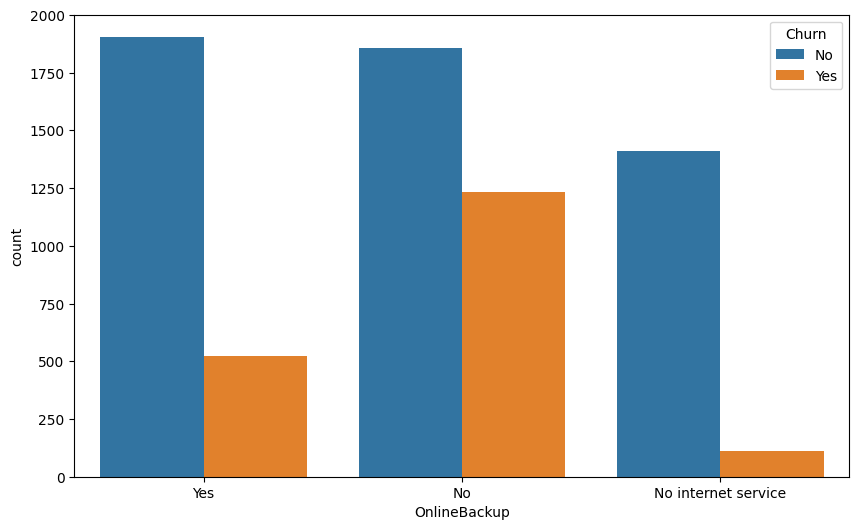

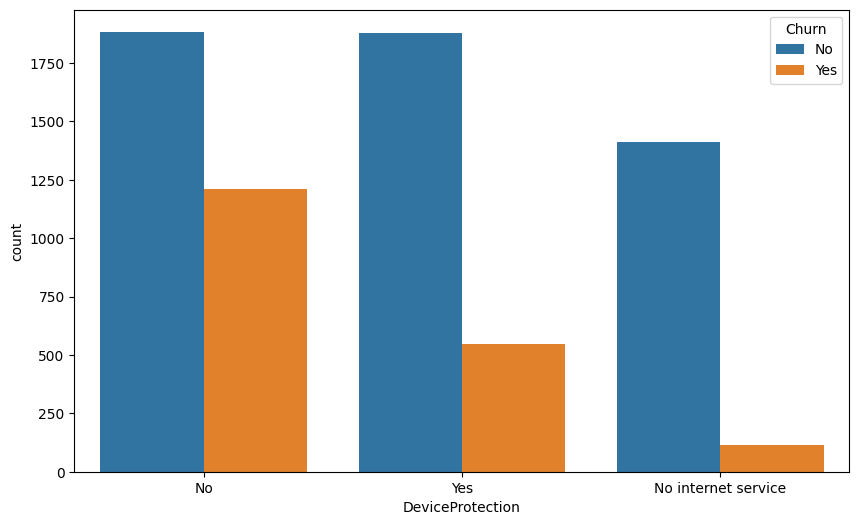

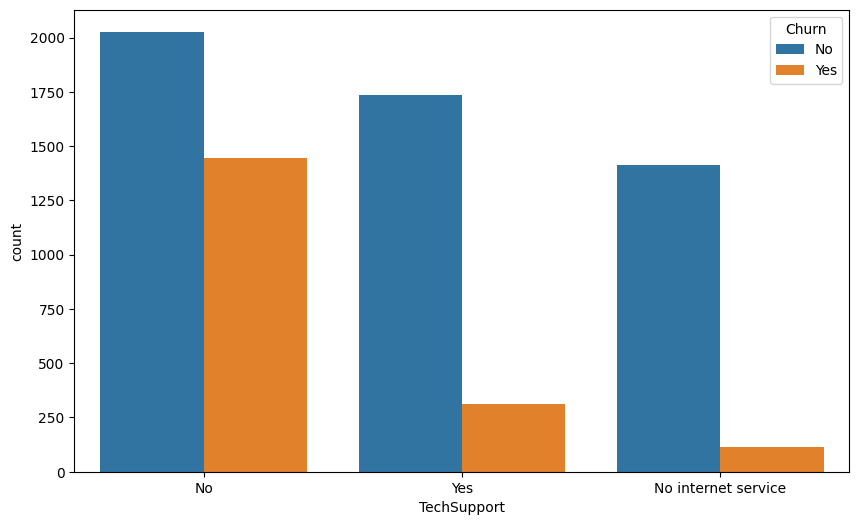

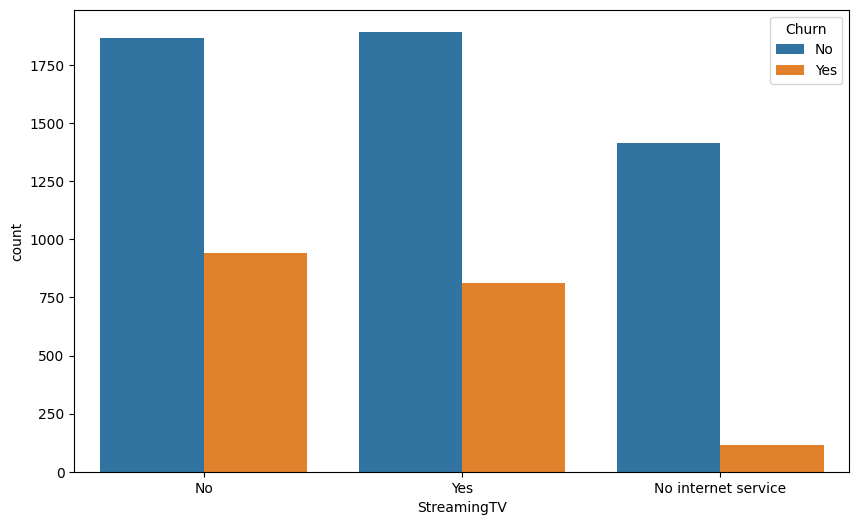

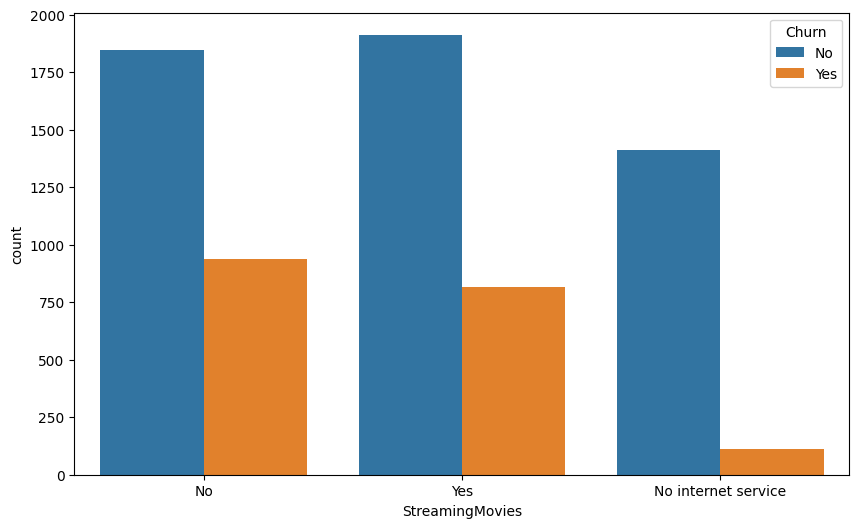

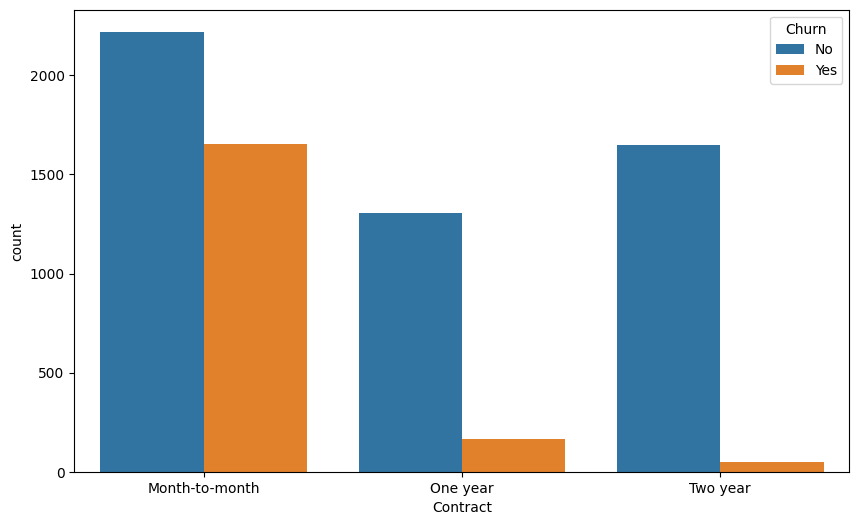

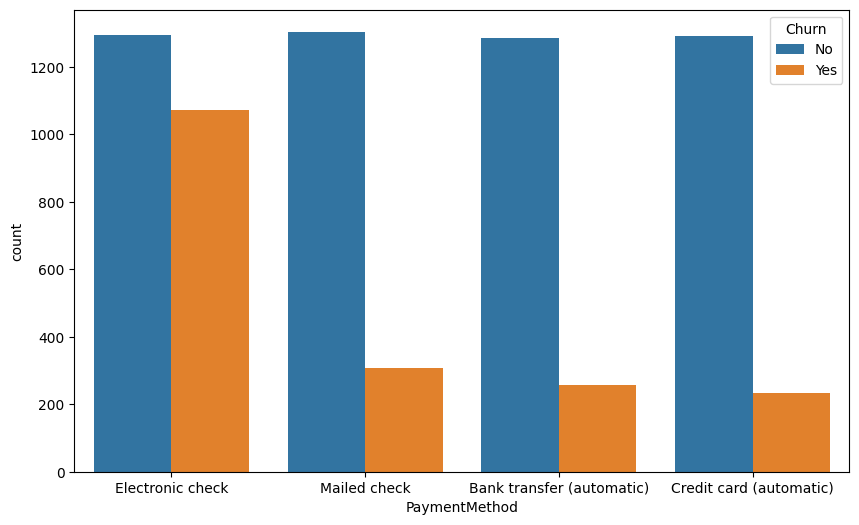

In [17]:
for col in categorical_features:
  print(pd.crosstab(df[col], df['Churn'],normalize='index')*100)
  plt.figure(figsize=(10,6))
  sns.countplot(x=col, hue='Churn', data=df)
  print("\n")

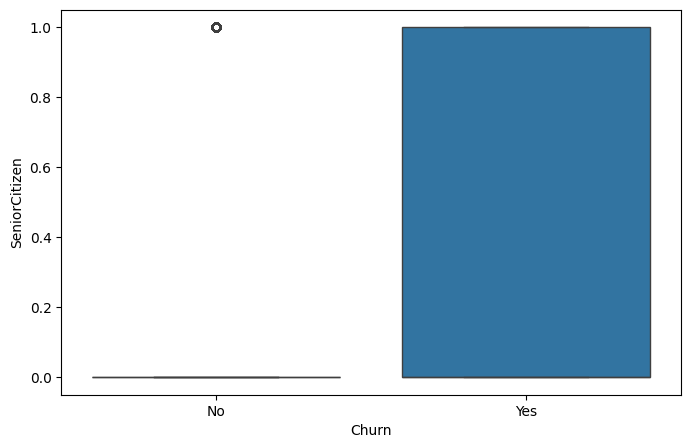

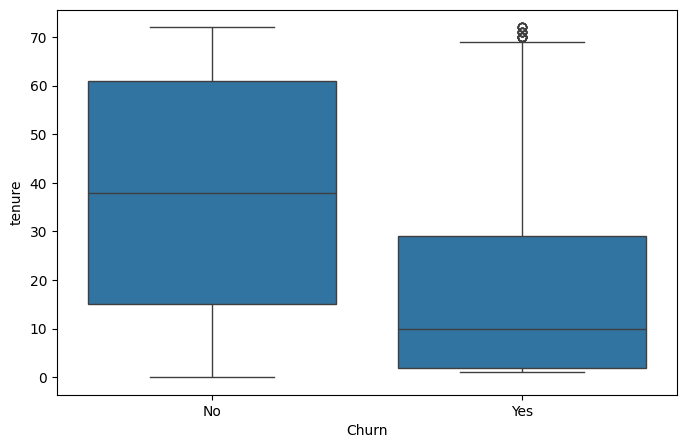

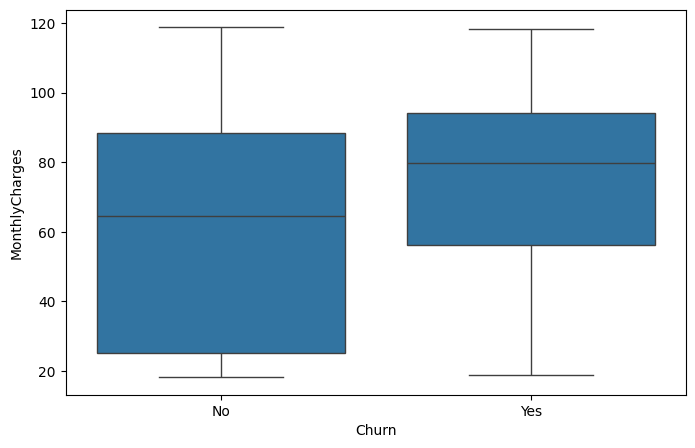

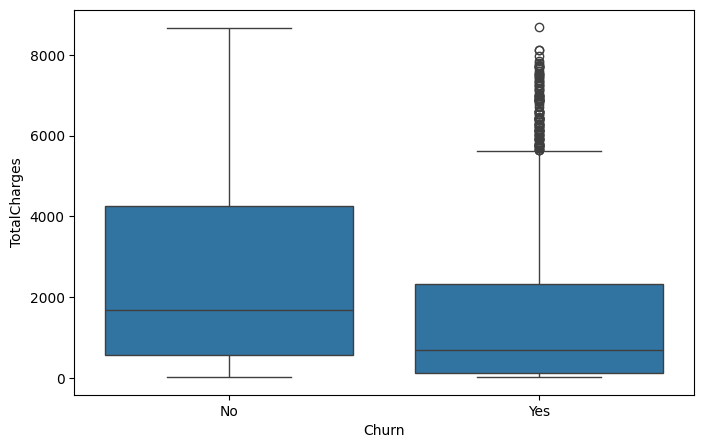

In [ ]:
for col in numeric_features:
  plt.figure(figsize=(8,5))
  sns.boxplot(x='Churn', y=col, data=df)

Tenure and TotalCharges show a strong positive correlation (~0.82),
which is expected since customers with longer tenure accumulate higher total charges.

MonthlyCharges and TotalCharges have moderate correlation (~0.65),
indicating total spending is partly driven by monthly fees.

MonthlyCharges and Tenure show weak correlation (~0.25),
suggesting monthly pricing is mostly independent of customer duration.

SeniorCitizen has very weak correlation with other variables,
indicating age group does not strongly influence charges or tenure.

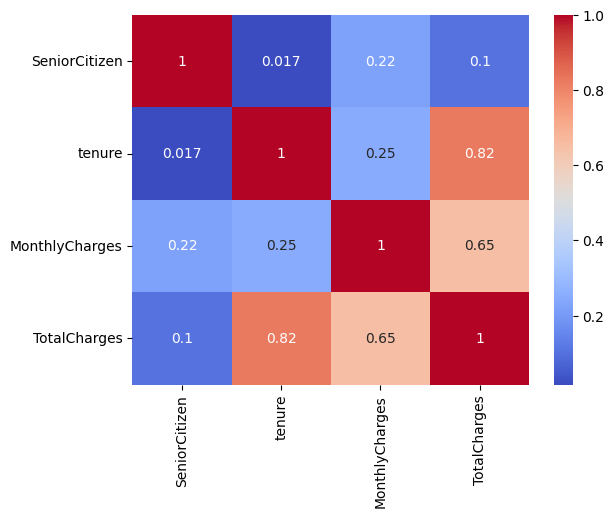

In [18]:
Numeric_corr=df[numeric_features].corr()
sns.heatmap(Numeric_corr, annot=True, cmap='coolwarm')
plt.show()

In [19]:
df_final= df[[
    "Contract",
    "PaymentMethod",
    "InternetService",
    "TechSupport",
    "OnlineSecurity",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "OnlineBackup",
    "DeviceProtection",
    "Churn"
]]

In [20]:
df_final.head()

,Contract,PaymentMethod,InternetService,TechSupport,OnlineSecurity,tenure,MonthlyCharges,TotalCharges,OnlineBackup,DeviceProtection,Churn
0,Month-to-month,Electronic check,DSL,No,No,1,29.85,29.85,Yes,No,No
1,One year,Mailed check,DSL,No,Yes,34,56.95,1889.50,No,Yes,No
2,Month-to-month,Mailed check,DSL,No,Yes,2,53.85,108.15,Yes,No,Yes
3,One year,Bank transfer (automatic),DSL,Yes,Yes,45,42.30,1840.75,No,Yes,No
4,Month-to-month,Electronic check,Fiber optic,No,No,2,70.70,151.65,No,No,Yes


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc
import optuna

In [30]:

num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection','Contract', 'PaymentMethod', 'InternetService']

In [31]:
X = df_final.drop("Churn", axis=1)
Y = df_final["Churn"]

In [32]:
Y = Y.map({'Yes': 1, 'No': 0})

In [33]:
classes = np.unique(Y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=Y
)
class_weight_dict = dict(zip(classes, class_weights))

In [41]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
])

preprocessing_Transformer=ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features),
],remainder='drop')

In [43]:
models={
    "Logistic Regression" : LogisticRegression(class_weight=class_weight_dict),
    "Random Forest Classifier" : RandomForestClassifier(class_weight=class_weight_dict),
    "Support Vector Machine" : SVC(class_weight=class_weight_dict),
    "Gradient Boosting Classifier" : GradientBoostingClassifier(),
    "XGBoost Classifier": XGBClassifier(scale_pos_weight=class_weight_dict[1])
}

In [44]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [45]:
result={}
for model_name , algorithm in models.items():
  model=Pipeline(
      steps=[
        ("preprocessor",preprocessing_Transformer),
        ("Model", algorithm )
        ]
  )

  scores = cross_val_score(model, x_train, y_train, cv=4, scoring='roc_auc')
  result[model_name]=scores.mean().tolist()

e:\Projects\Customer Churn Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
e:\Projects\Customer Churn Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/mod

In [47]:
print('ROC SCORE')
for model_name, roc_score in result.items():
    print(model_name, ":", roc_score)

ROC SCORE
Logistic Regression : 0.8329466660250693
Random Forest Classifier : 0.8119037108234016
Support Vector Machine : 0.7011776071248881
Gradient Boosting Classifier : 0.838669017203852
XGBoost Classifier : 0.8165905100913411


In [48]:
def objective(trial):
  n_estimators = trial.suggest_int('n_estimators', 100, 1000)
  learning_rate= trial.suggest_float("learning_rate", 0.01, 0.2)
  max_depth = trial.suggest_int('max_depth', 3, 10)

  best_model = Pipeline([
    ("preprocessor", preprocessing_Transformer),
    ("classifier",GradientBoostingClassifier(n_estimators=n_estimators,max_depth=max_depth,learning_rate=learning_rate,random_state=42))
])

  score = cross_val_score(
        best_model,
        x_train,
        y_train,
        cv=4,
        scoring="roc_auc"
        ).mean()

  return score

In [49]:
Study = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler())
Study.optimize(objective, n_trials=30)

[I 2026-04-02 18:00:32,893] A new study created in memory with name: no-name-693ad840-aede-4f75-bf78-b1173460c694
[I 2026-04-02 18:00:47,262] Trial 0 finished with value: 0.810327625990547 and parameters: {'n_estimators': 265, 'learning_rate': 0.085049067461348, 'max_depth': 9}. Best is trial 0 with value: 0.810327625990547.
[I 2026-04-02 18:01:02,877] Trial 1 finished with value: 0.7967346744815617 and parameters: {'n_estimators': 791, 'learning_rate': 0.17328651503429476, 'max_depth': 4}. Best is trial 0 with value: 0.810327625990547.
[I 2026-04-02 18:01:34,457] Trial 2 finished with value: 0.8081140341014962 and parameters: {'n_estimators': 495, 'learning_rate': 0.04695303575038326, 'max_depth': 10}. Best is trial 0 with value: 0.810327625990547.
[I 2026-04-02 18:02:01,626] Trial 3 finished with value: 0.8024802735687944 and parameters: {'n_estimators': 801, 'learning_rate': 0.09051268383222257, 'max_depth': 6}. Best is trial 0 with value: 0.810327625990547.
[I 2026-04-02 18:02:07,1

In [50]:
best_parameters=Study.best_params
print(f"{best_parameters}")

{'n_estimators': 101, 'learning_rate': 0.03141435635008687, 'max_depth': 4}


In [51]:
best_parameters["n_estimators"]

101

In [52]:
best_model = Pipeline([
    ("preprocessor", preprocessing_Transformer),
    ("classifier",GradientBoostingClassifier(n_estimators=best_parameters["n_estimators"],max_depth=best_parameters["max_depth"],learning_rate=best_parameters["learning_rate"],random_state=42))
])

In [53]:
history=best_model.fit(x_train, y_train)

In [54]:
import joblib
joblib.dump(best_model, 'churn_pipeline_v1.pkl')
print("Model saved successfully.")

Model saved successfully.


In [55]:
importance=best_model.named_steps['classifier'].feature_importances_.tolist()

In [56]:
ohe = best_model.named_steps['preprocessor'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(cat_features).tolist()

In [57]:
feature_names = num_features + cat_names
feature_Importance = {}

for i, feature in enumerate(feature_names):
    feature_Importance[feature] = importance[i]
sorted_features_Importance = sorted(feature_Importance.items(), key=lambda x: x[1], reverse=True)

In [58]:
for feature_name, imp in sorted_features_Importance:
    print(f"{feature_name}:{imp}")

tenure:0.35210967379446884
InternetService_Fiber optic:0.23377682034391736
PaymentMethod_Electronic check:0.10228999674259269
MonthlyCharges:0.06992349242924882
Contract_Two year:0.055867332886314236
TotalCharges:0.053357150655168925
Contract_One year:0.052354537001851845
OnlineSecurity_Yes:0.020036729296292424
TechSupport_Yes:0.014394173095000984
InternetService_No:0.009716792172028893
DeviceProtection_No internet service:0.008184301857628785
OnlineBackup_No internet service:0.00744936947890689
OnlineSecurity_No internet service:0.005889978601225639
OnlineBackup_Yes:0.004764084417680718
PaymentMethod_Mailed check:0.0036847793145899695
TechSupport_No internet service:0.0035462315061214962
PaymentMethod_Credit card (automatic):0.0016842038396251335
DeviceProtection_Yes:0.0009703525673365201


In [59]:
y_pred = history.predict(x_test)

In [60]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [62]:
print(classification_report(y_test, y_pred))
print(f"Accuracy of Model : {int(accuracy_score(y_test, y_pred)*100)}%")

              precision    recall  f1-score   support

           0       0.84      0.92      0.87      1036
           1       0.68      0.51      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Accuracy of Model : 80%


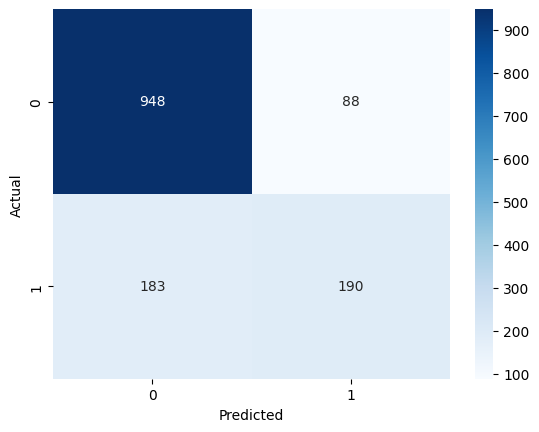

In [63]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

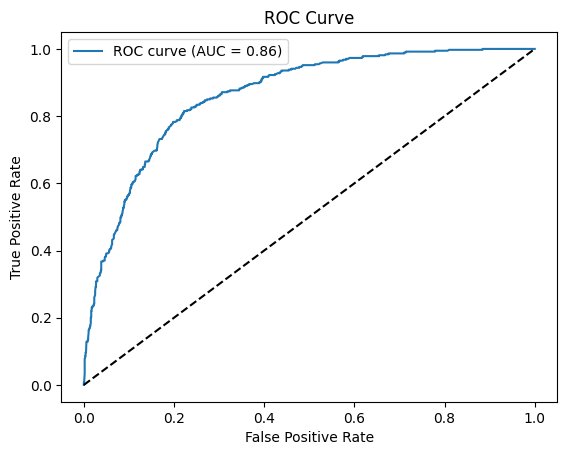

In [64]:
prob = best_model.predict_proba(x_test)
fpr, tpr, _ = roc_curve(y_test, prob[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [65]:
sample_data = pd.DataFrame([
    {
        "tenure": 1,
        "InternetService": "DSL",
        "OnlineSecurity": "No",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "TechSupport": "No",
        "Contract": "Month-to-month",
        "PaymentMethod": "Electronic check",
        "MonthlyCharges": 35.0,
        "TotalCharges": 35.0
    }])

In [66]:
prediction = best_model.predict(sample_data)
prob = best_model.predict_proba(sample_data)

print(prediction)
print(prob)

[1]
[[0.37057754 0.62942246]]


In [ ]:
import joblib
model = joblib.load("churn_pipeline_v1.pkl")